In [2]:
pip install tensorflow


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


   ---- ----------------------------------- 2.9/26.4 MB 509.8 kB/s eta 0:00:47
   ---- ----------------------------------- 2.9/26.4 MB 509.8 kB/s eta 0:00:47
   ---- ----------------------------------- 2.9/26.4 MB 509.8 kB/s eta 0:00:47
   ---- ----------------------------------- 2.9/26.4 MB 509.8 kB/s eta 0:00:47
   ---- ----------------------------------- 3.1/26.4 MB 464.7 kB/s eta 0:00:51
   ---- ----------------------------------- 3.1/26.4 MB 464.7 kB/s eta 0:00:51
   ---- ----------------------------------- 3.1/26.4 MB 464.7 kB/s eta 0:00:51
   ---- ----------------------------------- 3.1/26.4 MB 464.7 kB/s eta 0:00:51
   ----- ---------------------------------- 3.4/26.4 MB 450.5 kB/s eta 0:00:52
   ----- ---------------------------------- 3.4/26.4 MB 450.5 kB/s eta 0:00:52
   ----- ---------------------------------- 3.4/26.4 MB 450.5 kB/s eta 0:00:52
   ----- ---------------------------------- 3.7/26.4 MB 453.5 kB/s eta 0:00:51
   ----- ---------------------------------- 3.7/26.4

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()


26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 53s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


In [5]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [6]:
# Build CNN (6 layers)
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # 1
    layers.MaxPooling2D((2,2)),                                          # 2
    layers.Conv2D(64, (3,3), activation='relu'),                         # 3
    layers.MaxPooling2D((2,2)),                                          # 4
    layers.Flatten(),                                                    # 5
    layers.Dense(128, activation='relu'),                                # 6
    layers.Dense(10, activation='softmax')                               # Output
])

In [7]:
# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
# Train
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.6340 - loss: 0.9875 - val_accuracy: 0.7247 - val_loss: 0.7275
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.7482 - loss: 0.6653 - val_accuracy: 0.7550 - val_loss: 0.6529
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7748 - loss: 0.5961 - val_accuracy: 0.7827 - val_loss: 0.5831
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7952 - loss: 0.5483 - val_accuracy: 0.7899 - val_loss: 0.5585
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8090 - loss: 0.5160 - val_accuracy: 0.7997 - val_loss: 0.5423
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7997 - loss: 0.5423
Test Accuracy: 0.7997000217437744


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


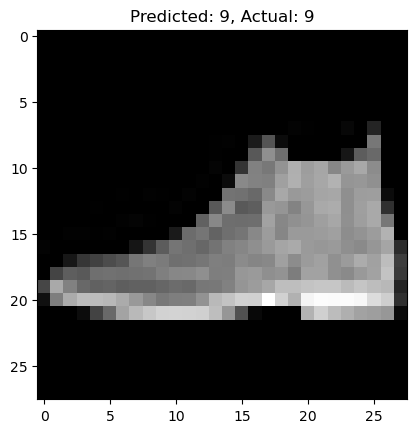

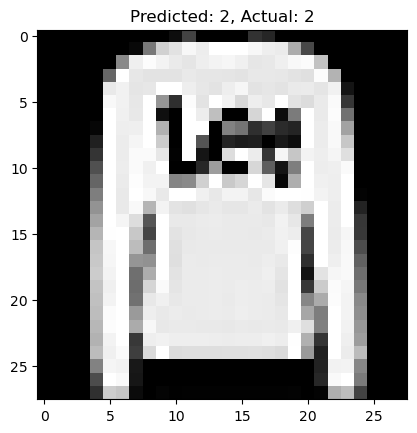

In [9]:
# Predictions for 2 images
predictions = model.predict(x_test)

for i in range(2):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}, Actual: {y_test[i]}")
    plt.show()

In [10]:
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [11]:
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


SyntaxError: invalid syntax (4287291548.py, line 1)

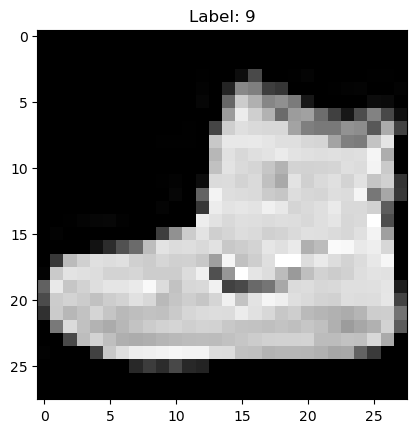

In [12]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()
